In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
from math import log
from sklearn.model_selection import train_test_split
from sklearn import tree

In [ ]:
#  Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar el archivo
pacientes = pd.read_csv('/content/drive/MyDrive/Minería de datos UNAB/Clase IX/TALLER/pacientes.csv')
pacientes.head()


,edad,colesterol,problema_cardiaco
0,63,233,1
1,37,250,1
2,41,204,1
3,56,236,1
4,57,354,1


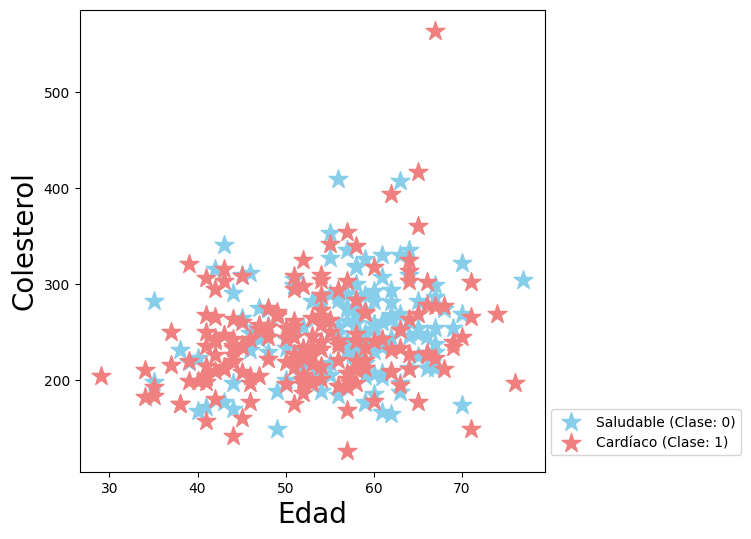

In [ ]:
#Gráfica dispersión: Edad y Colesterol
saludables = pacientes[pacientes["problema_cardiaco"]==0]
cardiacos = pacientes[pacientes["problema_cardiaco"]==1]

plt.figure(figsize=(6, 6))
plt.xlabel('Edad', fontsize = 20.0)
plt.ylabel('Colesterol', fontsize = 20.0)
plt.scatter(saludables["edad"], saludables["colesterol"],
            label="Saludable (Clase: 0)", marker="*", c="skyblue", s=200)
plt.scatter(cardiacos["edad"], cardiacos["colesterol"],
            label="Cardíaco (Clase: 1)", marker="*", c="lightcoral", s=200)
plt.legend(bbox_to_anchor=(1, 0.15))
plt.show()

In [ ]:
#Entropía:
#Promedio de información almacenada en una variable aleatoria

#print(log(8,2))
#print(entropy([1/2, 1/2], base=2))
#print(entropy([0/10, 10/10], base=2))

edades = pd.Series([40, 30, 20, 50])
colesterol = pd.Series([100, 110, 100, 110])

print(edades.value_counts()/edades.size)
print(colesterol.value_counts()/colesterol.size)
print(entropy(edades.value_counts()/edades.size, base=2))
print(entropy(colesterol.value_counts()/colesterol.size, base=2))

40    0.25
30    0.25
20    0.25
50    0.25
Name: count, dtype: float64
100    0.5
110    0.5
Name: count, dtype: float64
2.0
1.0


In [ ]:
#Datos de Entrenamiento y Prueba
datos_entrena, datos_prueba, clase_entrena, clase_prueba = train_test_split(
    pacientes[["edad", "colesterol"]],
    pacientes["problema_cardiaco"],
    test_size=0.30)


0.4777777777777778
|--- Edad <= 54.50
|   |--- Colesterol <= 278.50
|   |   |--- Edad <= 42.50
|   |   |   |--- Edad <= 40.50
|   |   |   |   |--- Colesterol <= 219.00
|   |   |   |   |   |--- Edad <= 36.00
|   |   |   |   |   |   |--- Colesterol <= 195.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Colesterol >  195.00
|   |   |   |   |   |   |   |--- Edad <= 34.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Edad >  34.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Edad >  36.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Colesterol >  219.00
|   |   |   |   |   |--- Colesterol <= 240.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Colesterol >  240.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- Edad >  40.50
|   |   |   |   |--- class: 1
|   |   |--- Edad >  42.50
|   |   |   |--- Colesterol <= 267.50
|   |   |   |   |--- Colesterol <= 164.50
|   |   | 

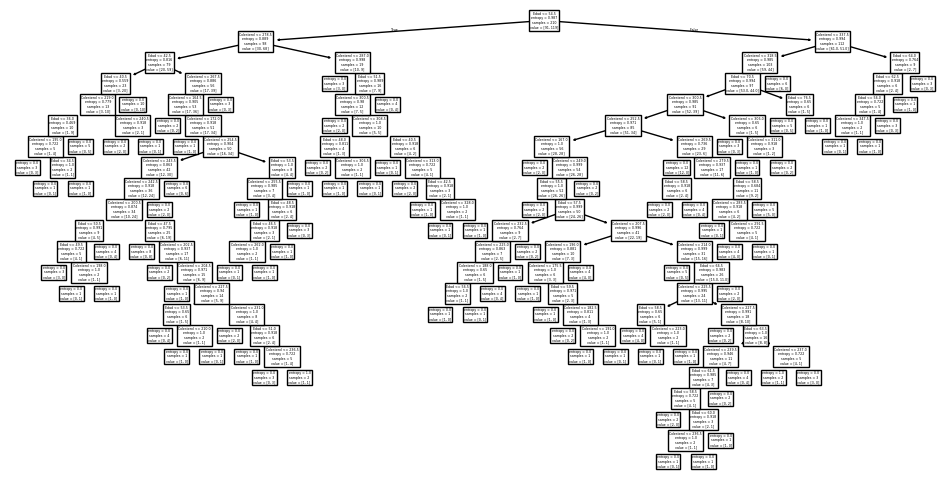

In [ ]:
#Creación del Árbol de Decisión

arbol_decision = tree.DecisionTreeClassifier(criterion="entropy")

arbol = arbol_decision.fit(datos_entrena, clase_entrena)

accuracy = arbol_decision.score(datos_prueba, clase_prueba)

print(accuracy)

print(tree.export_text(arbol,
                      feature_names=["Edad", "Colesterol"]))
plt.figure(figsize=(12, 6))
tree.plot_tree(arbol,
              feature_names=["Edad", "Colesterol"])
plt.show()

In [ ]:
#Clasifica a nuevos pacientes
print("Nuevo paciente", arbol_decision.predict([[70, 150]]))

Nuevo paciente [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
